# Experiment 1 · Notebook 2 — Train POW Model

**Goal:** Predict OOTP's `POW` rating (20–80 scale) from career HR rate and handedness. Train two baselines and compare.

**Inputs:** `data/training_data.csv` from notebook 1.

**Outputs:** plots + `outputs/metrics.json`.

**Targets from the plan:** MAE < 6 and R² > 0.6 on a held-out 20% test split.

## 1. Setup

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import max_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

TRAINING_PATH      = Path("data/training_data.csv")
PLOT_HR_VS_POW     = Path("outputs/hr_rate_vs_pow.png")
PLOT_PRED_V_ACTUAL = Path("outputs/predicted_vs_actual.png")
PLOT_RESIDUALS     = Path("outputs/residuals.png")
METRICS_JSON       = Path("outputs/metrics.json")

PLOT_HR_VS_POW.parent.mkdir(parents=True, exist_ok=True)

FEATURE_COLS = ["hr_per_600", "bats_L", "bats_S"]
TARGET_COL   = "POW"
RANDOM_STATE = 42
TEST_SIZE    = 0.20


## 2. Load data and split

In [2]:
df = pd.read_csv(TRAINING_PATH)
print(f"Loaded {len(df)} rows from {TRAINING_PATH}")

X = df[FEATURE_COLS]
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f"Train/test split: {len(X_train)} / {len(X_test)}")


Loaded 441 rows from data/training_data.csv
Train/test split: 352 / 89


## 3. Linear regression

One-feature linear with handedness offsets. The slope is directly interpretable: "each additional HR/600 PA adds X points to predicted POW."

In [3]:
model_lr = LinearRegression().fit(X_train, y_train)

print("Linear coefficients:")
for name, coef in zip(FEATURE_COLS, model_lr.coef_):
    print(f"  {name:>12}: {coef:+.3f}")
print(f"  {'intercept':>12}: {model_lr.intercept_:+.3f}")


Linear coefficients:
    hr_per_600: +1.384
        bats_L: +1.653
        bats_S: +1.446
     intercept: +22.247


In [4]:
y_pred_lr = model_lr.predict(X_test)
metrics_lr = {
    "model": "linear",
    "mae": float(mean_absolute_error(y_test, y_pred_lr)),
    "r2": float(r2_score(y_test, y_pred_lr)),
    "max_error": float(max_error(y_test, y_pred_lr)),
}
metrics_lr


{'model': 'linear',
 'mae': 5.22031982400733,
 'r2': 0.6971289455072008,
 'max_error': 25.816938925912908}

## 4. Polynomial regression (degree 2)

Quadratic on `hr_per_600` to allow gentle curvature near the rating boundaries. If polynomial doesn't beat linear meaningfully, the relationship is essentially linear in the feature range we observe.

In [5]:
model_poly = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression(),
).fit(X_train, y_train)

y_pred_poly = model_poly.predict(X_test)
metrics_poly = {
    "model": "polynomial_deg2",
    "mae": float(mean_absolute_error(y_test, y_pred_poly)),
    "r2": float(r2_score(y_test, y_pred_poly)),
    "max_error": float(max_error(y_test, y_pred_poly)),
}
metrics_poly


{'model': 'polynomial_deg2',
 'mae': 5.138742360634068,
 'r2': 0.703634287807607,
 'max_error': 25.408563785775826}

## 5. Side-by-side metrics

In [6]:
summary = pd.DataFrame([metrics_lr, metrics_poly]).round(
    {"mae": 2, "r2": 3, "max_error": 2}
)
summary


,model,mae,r2,max_error
0,linear,5.22,0.697,25.82
1,polynomial_deg2,5.14,0.704,25.41


## 6. Sanity check predictions

Pick a high-power, median-power, and low-power player and eyeball the predictions against their actual OOTP ratings.

In [7]:
targets = [("judgeaa01", "Aaron Judge (high power)")]

median_row = df.iloc[(df["POW"] - df["POW"].median()).abs().argsort()[:1]].iloc[0]
targets.append((median_row["HistID"], f"{median_row['Name']} (median POW)"))

low_row = df.nsmallest(1, "POW").iloc[0]
targets.append((low_row["HistID"], f"{low_row['Name']} (low POW)"))

sanity = []
for hist_id, label in targets:
    match = df[df["HistID"] == hist_id]
    if match.empty:
        continue
    row = match.iloc[0]
    X_p = match[FEATURE_COLS]
    pred_lr   = float(model_lr.predict(X_p)[0])
    pred_poly = float(model_poly.predict(X_p)[0])
    print(f"{label:<35} actual={row['POW']:>2}  HR/600={row['hr_per_600']:>5.1f}  linear={pred_lr:>5.1f}  poly={pred_poly:>5.1f}")
    sanity.append({"label": label, "hist_id": hist_id, "name": row["Name"],
                   "actual_pow": int(row["POW"]),
                   "hr_per_600": float(row["hr_per_600"]),
                   "predicted_linear": pred_lr,
                   "predicted_polynomial": pred_poly})


Aaron Judge (high power)            actual=80  HR/600= 44.3  linear= 83.6  poly= 82.6
Bo Bichette (median POW)            actual=45  HR/600= 19.8  linear= 49.6  poly= 49.4
Ezequiel Duran (low POW)            actual=20  HR/600= 11.2  linear= 37.7  poly= 38.1


## 7. Plots

Three diagnostic plots: scatter with fit lines, predicted-vs-actual, and residuals.

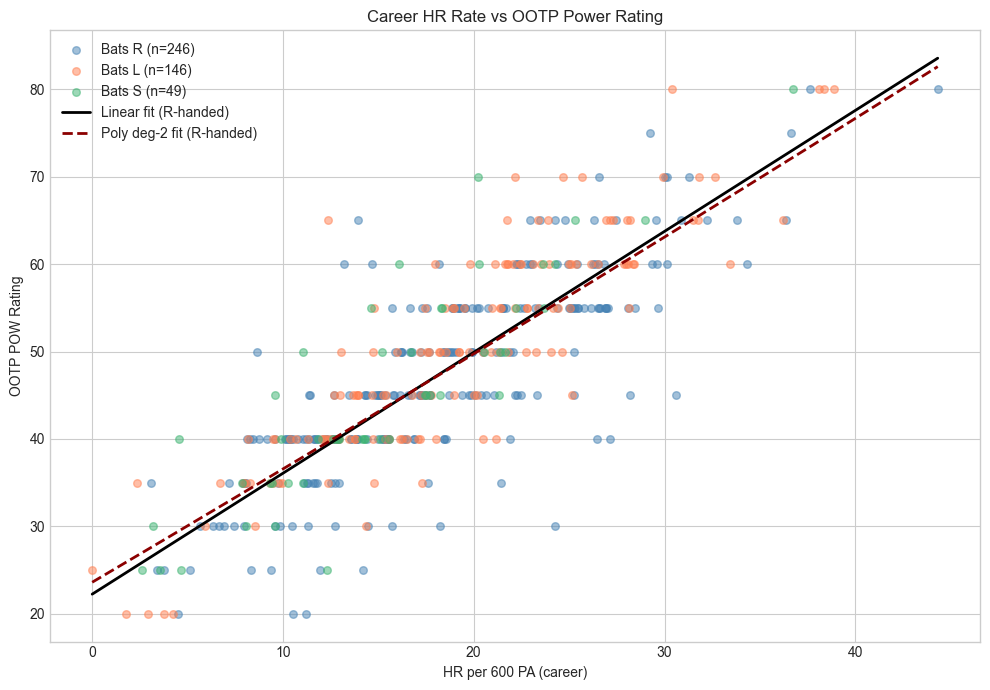

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = {"R": "steelblue", "L": "coral", "S": "mediumseagreen"}
for bats, color in colors.items():
    mask = df["bats"] == bats
    ax.scatter(df.loc[mask, "hr_per_600"], df.loc[mask, "POW"],
               alpha=0.5, label=f"Bats {bats} (n={int(mask.sum())})",
               color=color, s=30)

x_grid = np.linspace(df["hr_per_600"].min(), df["hr_per_600"].max(), 200)
grid_df = pd.DataFrame({"hr_per_600": x_grid, "bats_L": 0, "bats_S": 0})
ax.plot(x_grid, model_lr.predict(grid_df), color="black",
        linewidth=2, label="Linear fit (R-handed)")
ax.plot(x_grid, model_poly.predict(grid_df), color="darkred",
        linewidth=2, linestyle="--", label="Poly deg-2 fit (R-handed)")

ax.set_xlabel("HR per 600 PA (career)")
ax.set_ylabel("OOTP POW Rating")
ax.set_title("Career HR Rate vs OOTP Power Rating")
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_HR_VS_POW, dpi=130)
plt.show()


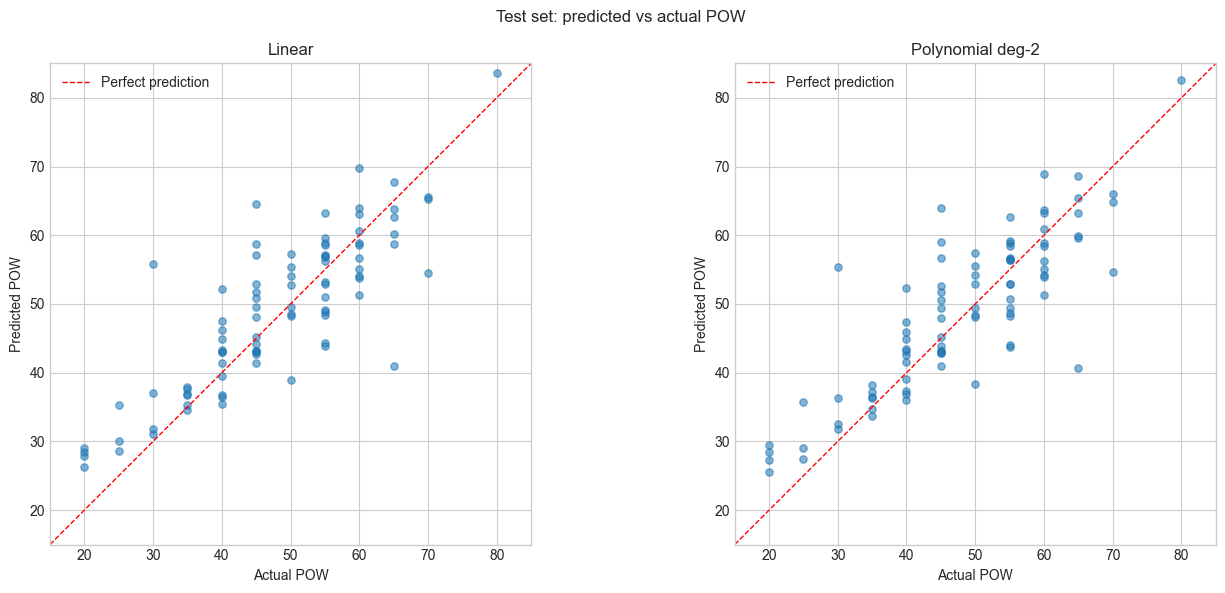

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, model) in zip(axes, [("Linear", model_lr), ("Polynomial deg-2", model_poly)]):
    yp = model.predict(X_test)
    ax.scatter(y_test, yp, alpha=0.55, s=28)
    lims = [15, 85]
    ax.plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Actual POW"); ax.set_ylabel("Predicted POW")
    ax.set_title(name)
    ax.legend(loc="upper left")
    ax.set_aspect("equal")
fig.suptitle("Test set: predicted vs actual POW")
fig.tight_layout()
fig.savefig(PLOT_PRED_V_ACTUAL, dpi=130)
plt.show()


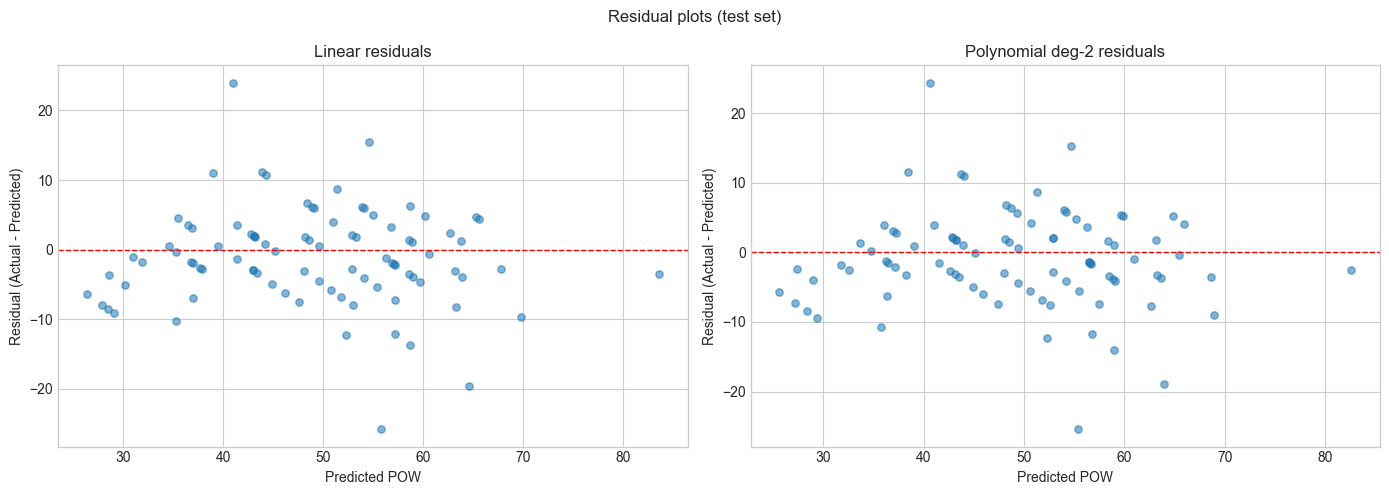

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, model) in zip(axes, [("Linear", model_lr), ("Polynomial deg-2", model_poly)]):
    yp = model.predict(X_test)
    resid = y_test - yp
    ax.scatter(yp, resid, alpha=0.55, s=28)
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.set_xlabel("Predicted POW"); ax.set_ylabel("Residual (Actual - Predicted)")
    ax.set_title(f"{name} residuals")
fig.suptitle("Residual plots (test set)")
fig.tight_layout()
fig.savefig(PLOT_RESIDUALS, dpi=130)
plt.show()


## 8. Persist machine-readable summary

Write `outputs/metrics.json` for the experiment writeup.

In [11]:
summary_dict = {
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "pa_threshold": int(df["PA"].min()),
    "feature_cols": FEATURE_COLS,
    "linear": {
        "coef": dict(zip(FEATURE_COLS, [float(c) for c in model_lr.coef_])),
        "intercept": float(model_lr.intercept_),
        "metrics": metrics_lr,
    },
    "polynomial_deg2": {"metrics": metrics_poly},
    "sanity_checks": sanity,
}
METRICS_JSON.write_text(json.dumps(summary_dict, indent=2))
print(f"wrote {METRICS_JSON}")


wrote outputs/metrics.json


## 9. Targets check

In [12]:
best = min([metrics_lr, metrics_poly], key=lambda m: m['mae'])
print(f"Best by MAE: {best['model']}")
print(f"  MAE = {best['mae']:.2f}  ({'PASS' if best['mae'] < 6 else 'MISS'} target < 6)")
print(f"  R²  = {best['r2']:.3f}  ({'PASS' if best['r2'] > 0.6 else 'MISS'} target > 0.6)")


Best by MAE: polynomial_deg2
  MAE = 5.14  (PASS target < 6)
  R²  = 0.704  (PASS target > 0.6)
